<a href="https://colab.research.google.com/github/SiyuL2025/math_629_final/blob/main/CNN_v15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN LOB -- v15: LSTM-Style Threshold Sweep + Anti-Overfitting

**Changes from v14:**
- **Anti-overfitting**: Removed SEBlock and TemporalAttention (saved ~1M params), N_FILTERS 128→64, DROPOUT 0.1→0.3, WD 1e-3→1e-2, OneCycleLR→CosineAnnealingLR, LR 3e-4→1e-4
- **EMBARGO_GAP=10**: Skip 10 rows between train/test (matches LSTM, prevents boundary leakage)
- **FEE = 0.00015 (1.5 bps)**: Matches LSTM; 15 bps is structurally unviable at second-level data
- **LSTM-style threshold sweep**: Per-class thresholding `preds[probs[:,0]>th]=0; preds[probs[:,2]>th]=2` instead of max-prob gating
- **Dual-axis sweep plot**: Sharpe (red) vs Total Trades (blue) to find the sweet spot
- `run_cnn()` runs argmax backtest + sweep + optimal-threshold backtest for all 3 feature sets

In [1]:
import math, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import gc

from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/629/'
df_full      = pd.read_csv(DATA_PATH + 'lob_full_v4.csv')
df_no_pca    = pd.read_csv(DATA_PATH + 'lob_no_pca_v4.csv')
df_no_market = pd.read_csv(DATA_PATH + 'lob_no_market_v4.csv')

META_COLS = ['label', 'future_return', 'split']
full_feat_cols      = [c for c in df_full.columns      if c not in META_COLS]
no_pca_feat_cols    = [c for c in df_no_pca.columns    if c not in META_COLS]
no_market_feat_cols = [c for c in df_no_market.columns if c not in META_COLS]

split_idx = int((df_full['split'] == 'train').sum())

print('lob_full      shape:', df_full.shape,      '| features:', len(full_feat_cols))
print('lob_no_pca    shape:', df_no_pca.shape,    '| features:', len(no_pca_feat_cols))
print('lob_no_market shape:', df_no_market.shape, '| features:', len(no_market_feat_cols))
print('Train rows:', split_idx, '| Test rows:', len(df_full) - split_idx)
gc.collect()

Mounted at /content/drive
lob_full      shape: (99783, 41) | features: 38
lob_no_pca    shape: (99783, 91) | features: 88
lob_no_market shape: (99783, 26) | features: 23
Train rows: 79826 | Test rows: 19957


0

In [2]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
SEED        = 42
SEQ_LEN     = 10
N_FILTERS   = 64       # v14 used 128 → overfit; back to v12 level
KERNEL_SIZE = 3
N_BLOCKS    = 2
DROPOUT     = 0.3      # v14=0.1 → much more regularisation (LSTM uses 0.4)
BATCH_SIZE  = 256
EPOCHS      = 50
LR          = 1e-4     # v14=3e-4 → slower, less likely to memorise noise
PATIENCE    = 10
WD          = 1e-2     # v14=1e-3 → 10× stronger L2 penalty
EMBARGO_GAP = 10       # skip 10 rows between train/test (matches LSTM)

# ── Trading parameters ───────────────────────────────────────────────────────
FEE = 0.00015          # 1.5 bps — matches LSTM; 15 bps is unviable at 1-second data

torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print(f'Config — N_FILTERS={N_FILTERS} | DROPOUT={DROPOUT} | WD={WD} | LR={LR}')
print(f'Trading — Fee={FEE*10000:.1f} bps | EMBARGO_GAP={EMBARGO_GAP}')


def select_features(feature_set):
    if feature_set == 'full':
        df, feat_cols = df_full, full_feat_cols
    elif feature_set == 'no_pca':
        df, feat_cols = df_no_pca, no_pca_feat_cols
    elif feature_set == 'no_market':
        df, feat_cols = df_no_market, no_market_feat_cols
    else:
        raise ValueError('Unknown feature_set: ' + feature_set)
    print('Feature set:', feature_set.upper(), '| features:', len(feat_cols))
    X = df[feat_cols].values.astype(np.float32)
    y = (df['label'].values + 1).astype(np.int64)   # {-1,0,1} → {0,1,2}
    print('X shape:', X.shape, '| y shape:', y.shape)
    print('Label dist (down/flat/up):',
          np.round(np.bincount(y, minlength=3) / len(y), 3))
    return X, y


class LOBDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X       = torch.tensor(X, dtype=torch.float32)
        self.y       = torch.tensor(y, dtype=torch.long)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len + 1

    def __getitem__(self, i):
        return self.X[i : i + self.seq_len], self.y[i + self.seq_len - 1]


def build_loaders(X, y):
    """EMBARGO_GAP=10 matches LSTM: skip 10 rows at train/test boundary."""
    local_split = min(split_idx, len(X) - 1)
    X_tr = X[:local_split]
    X_te = X[local_split + EMBARGO_GAP:]
    y_tr = y[:local_split]
    y_te = y[local_split + EMBARGO_GAP:]

    y_tr_targets = y_tr[SEQ_LEN - 1:]
    counts  = np.bincount(y_tr_targets, minlength=3).astype(float)
    class_w = torch.tensor(counts.sum() / (3 * counts),
                            dtype=torch.float32).to(DEVICE)

    train_loader = DataLoader(LOBDataset(X_tr, y_tr, SEQ_LEN),
                              batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(LOBDataset(X_te, y_te, SEQ_LEN),
                              batch_size=BATCH_SIZE * 2, shuffle=False)

    print('Train samples:', len(train_loader.dataset),
          '| Test samples:', len(test_loader.dataset))
    print('Class weights (down/flat/up):', class_w.cpu().numpy().round(3))
    return train_loader, test_loader, class_w

Device: cuda
Config — N_FILTERS=64 | DROPOUT=0.3 | WD=0.01 | LR=0.0001
Trading — Fee=1.5 bps | EMBARGO_GAP=10


## CNN Architecture (v15 — lean, no SE/TemporalAttention)

Key change from v14: removed SEBlock and TemporalAttention. Those two modules added ~1M parameters for marginal accuracy gain, which was the primary source of overfitting (train loss 0.24 vs val loss 2.72). The v15 architecture returns to the v12 parameter budget (~317K) while adding stronger regularization.

In [3]:
class ResidualBlock1D(nn.Module):
    """Simple residual block — no SE attention to keep parameter count low."""
    def __init__(self, in_channels, out_channels, kernel_size=3, dropout=0.3):
        super().__init__()
        pad = kernel_size // 2
        self.conv1   = nn.Conv1d(in_channels,  out_channels, kernel_size, padding=pad)
        self.bn1     = nn.BatchNorm1d(out_channels)
        self.conv2   = nn.Conv1d(out_channels, out_channels, kernel_size, padding=pad)
        self.bn2     = nn.BatchNorm1d(out_channels)
        self.skip    = (nn.Conv1d(in_channels, out_channels, kernel_size=1)
                        if in_channels != out_channels else nn.Identity())
        self.act     = nn.GELU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        residual = self.skip(x)
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.dropout(self.act(out + residual))


class LOBCNN(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Conv1d(n_features, N_FILTERS, kernel_size=1),
            nn.BatchNorm1d(N_FILTERS), nn.GELU()
        )
        res_blocks, in_ch = [], N_FILTERS
        for i in range(N_BLOCKS):
            out_ch = min(N_FILTERS * (2 ** i), N_FILTERS * 4)
            res_blocks.append(ResidualBlock1D(in_ch, out_ch, KERNEL_SIZE, DROPOUT))
            in_ch = out_ch
        self.res_blocks = nn.Sequential(*res_blocks)
        # Last-timestep pooling (simpler than TemporalAttention, fewer params)
        self.head = nn.Sequential(
            nn.Linear(in_ch, in_ch // 2), nn.GELU(),
            nn.Dropout(DROPOUT), nn.Linear(in_ch // 2, 3)
        )
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        x = x.permute(0, 2, 1)       # (B, T, F) → (B, F, T)
        x = self.input_proj(x)
        x = self.res_blocks(x)
        x = x[:, :, -1]              # last-timestep pooling
        return self.head(x)


def build_model(n_features):
    model    = LOBCNN(n_features).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print('Model params: %s  |  Input features: %d' % (f'{n_params:,}', n_features))
    return model

## Training

Key changes from v14:
- **CosineAnnealingLR** (not OneCycleLR): OneCycleLR aggressively raises then lowers LR, causing the model to memorize training data rapidly. CosineAnnealingLR is smoother and matches LSTM's scheduler.
- **DirF1 early stopping**: macro F1 over Down+Up classes only — same as v12/v13/v14.

In [4]:
def train(model, train_loader, test_loader, class_w):
    criterion = nn.CrossEntropyLoss(weight=class_w)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
    # CosineAnnealingLR: smooth decay, no aggressive ramp-up that causes overfitting
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS
    )

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_dir_f1': []}
    best_dir_f1, best_state, patience_cnt = 0.0, None, 0

    for epoch in range(1, EPOCHS + 1):
        model.train(); running = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running += loss.item() * len(yb)
        scheduler.step()
        train_loss = running / len(train_loader.dataset)

        model.eval()
        vloss, correct, total = 0.0, 0, 0
        ep_preds, ep_true = [], []
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb  = Xb.to(DEVICE), yb.to(DEVICE)
                logits   = model(Xb)
                vloss   += criterion(logits, yb).item() * len(yb)
                preds    = logits.argmax(1)
                correct += (preds == yb).sum().item()
                total   += len(yb)
                ep_preds.append(preds.cpu().numpy())
                ep_true.append(yb.cpu().numpy())

        val_loss = vloss / total
        val_acc  = correct / total
        all_preds = np.concatenate(ep_preds)
        all_true  = np.concatenate(ep_true)
        dir_f1 = f1_score(all_true, all_preds,
                          labels=[0, 2], average='macro', zero_division=0)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_dir_f1'].append(dir_f1)

        print('Ep %3d/%d | Train %.4f | Val %.4f | Acc %.4f | DirF1 %.4f'
              % (epoch, EPOCHS, train_loss, val_loss, val_acc, dir_f1))

        if dir_f1 > best_dir_f1:
            best_dir_f1, patience_cnt = dir_f1, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print('Early stop at epoch %d. Best DirF1: %.4f' % (epoch, best_dir_f1))
                break

    model.load_state_dict(best_state)
    return history, best_dir_f1


def evaluate(model, test_loader):
    """Returns predictions, true labels, and softmax probabilities."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for Xb, yb in test_loader:
            logits = model(Xb.to(DEVICE))
            probs  = torch.softmax(logits, dim=-1)
            all_preds.append(logits.argmax(1).cpu().numpy())
            all_probs.append(probs.cpu().numpy())
            all_labels.append(yb.numpy())
    y_pred = np.concatenate(all_preds)
    y_prob = np.concatenate(all_probs)   # (N, 3)
    y_true = np.concatenate(all_labels)
    print(classification_report(y_true, y_pred,
                                target_names=['Down', 'Flat', 'Up'],
                                zero_division=0))
    return y_pred, y_true, y_prob


def plot_training(history, y_pred, y_true, title=''):
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle('CNN LOB v15 -- ' + title, fontsize=14)
    ep = range(1, len(history['train_loss']) + 1)
    axes[0].plot(ep, history['train_loss'], label='Train', color='steelblue')
    axes[0].plot(ep, history['val_loss'],   label='Val',   color='tomato')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(ep, history['val_acc'], color='seagreen')
    axes[1].axhline(max(history['val_acc']), color='tomato', linestyle='--',
                    label='Best=%.4f' % max(history['val_acc']))
    axes[1].set_title('Val Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[2].plot(ep, history['val_dir_f1'], color='darkorange')
    axes[2].axhline(max(history['val_dir_f1']), color='tomato', linestyle='--',
                    label='Best=%.4f' % max(history['val_dir_f1']))
    axes[2].set_title('Directional F1'); axes[2].legend(); axes[2].grid(alpha=0.3)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[3],
                xticklabels=['Down', 'Flat', 'Up'],
                yticklabels=['Down', 'Flat', 'Up'])
    axes[3].set_title('Confusion Matrix')
    axes[3].set_xlabel('Predicted'); axes[3].set_ylabel('True')
    plt.tight_layout(); plt.show()

## Backtest Engine + LSTM-Style Threshold Sweep

**Why per-class thresholding (LSTM style) instead of max-prob gating (v14)?**

- v14 used `max_prob >= threshold` to gate all trades. This treats Down and Up symmetrically but requires the highest-probability class to exceed the bar. If the model gives 0.40 Down / 0.35 Flat / 0.25 Up, a 0.42 threshold blocks the trade even though Down has clear conviction.
- LSTM uses per-class thresholding: `probs[:,0] > th` triggers a Short, `probs[:,2] > th` triggers a Long. This directly asks "is the Down/Up class probability high enough?" — which is what we actually care about.
- Threshold sweep over 0.35→0.675 at step 0.025 (14 thresholds) finds the Sharpe-maximizing value rather than hand-tuning.

In [5]:
def simple_backtest(y_pred_labels, future_returns, fee=FEE, exp_name='Strategy'):
    """
    Compounding backtest.
    y_pred_labels : np.ndarray {0=Down, 1=Flat, 2=Up}
    future_returns: np.ndarray aligned true returns
    """
    signals           = y_pred_labels - 1
    trades            = np.abs(np.diff(signals, prepend=0))
    transaction_costs = trades * fee
    net_returns       = (signals * future_returns) - transaction_costs
    cum_returns       = np.cumprod(1 + net_returns)

    total_return  = cum_returns[-1] - 1
    annual_factor = 365 * 24 * 3600
    sharpe        = np.mean(net_returns) / (np.std(net_returns) + 1e-8) * np.sqrt(annual_factor)
    running_max   = np.maximum.accumulate(cum_returns)
    max_drawdown  = np.min((cum_returns - running_max) / running_max)
    active        = signals != 0
    win_rate      = (net_returns[active] > 0).sum() / (active.sum() + 1e-8)
    turnover      = int(trades.sum())

    print('\n' + '-' * 55)
    print(f'  BACKTEST: {exp_name}  (Fee: {fee*10000:.1f} bps)')
    print('-' * 55)
    print(f'  Total Net Return : {total_return:>10.2%}')
    print(f'  Annualized Sharpe: {sharpe:>10.2f}')
    print(f'  Max Drawdown     : {max_drawdown:>10.2%}')
    print(f'  Win Rate         : {win_rate:>10.2%}')
    print(f'  Active steps     : {active.sum():>10,} / {len(signals):,}  ({active.mean():.1%})')
    print(f'  Total Turnover   : {turnover:>10,}  (position changes)')

    return cum_returns, total_return, sharpe, max_drawdown


def sweep_thresholds(y_prob, future_returns, fee=FEE, exp_name=''):
    """
    LSTM-style per-class threshold sweep.
    For each threshold th:
      - Start with all Flat predictions
      - Override to Down (0) where probs[:,0] > th
      - Override to Up  (2) where probs[:,2] > th
    Find the threshold maximising the annualised Sharpe ratio.
    """
    print('\n' + '=' * 60)
    print(f'THRESHOLD SWEEP — {exp_name}  (Fee: {fee*10000:.1f} bps)')
    print('=' * 60)

    thresholds = np.arange(0.35, 0.675, 0.025)
    results = []
    annual_factor = 365 * 24 * 3600

    for th in thresholds:
        preds = np.ones(len(y_prob), dtype=np.int64)   # default Flat
        preds[y_prob[:, 0] > th] = 0   # Down
        preds[y_prob[:, 2] > th] = 2   # Up

        signals = preds - 1
        trades  = np.abs(np.diff(signals, prepend=0))
        net_ret = (signals * future_returns) - (trades * fee)
        cum_ret = np.cumprod(1 + net_ret)

        sharpe    = np.mean(net_ret) / (np.std(net_ret) + 1e-8) * np.sqrt(annual_factor)
        total_ret = cum_ret[-1] - 1
        results.append({
            'Threshold'    : th,
            'Total Return' : total_ret,
            'Sharpe Ratio' : sharpe,
            'Total Trades' : int(trades.sum())
        })

    df_res   = pd.DataFrame(results)
    best_idx = df_res['Sharpe Ratio'].idxmax()
    best_row = df_res.loc[best_idx]

    print(f'Best threshold : {best_row["Threshold"]:.3f}')
    print(f'  Sharpe       : {best_row["Sharpe Ratio"]:.2f}')
    print(f'  Net Return   : {best_row["Total Return"]:.2%}')
    print(f'  Turnover     : {best_row["Total Trades"]:,}')

    # Dual-axis plot: Sharpe (red) vs Total Trades (blue)
    fig, ax1 = plt.subplots(figsize=(10, 5))
    color1 = 'tab:red'
    ax1.set_xlabel('Model Confidence Threshold')
    ax1.set_ylabel('Annualized Sharpe Ratio', color=color1, fontweight='bold')
    l1 = ax1.plot(df_res['Threshold'], df_res['Sharpe Ratio'],
                  color=color1, marker='o', label='Sharpe Ratio')
    ax1.axvline(best_row['Threshold'], color=color1, linestyle=':', alpha=0.6,
                label=f'Best th={best_row["Threshold"]:.3f}')
    ax1.tick_params(axis='y', labelcolor=color1); ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    color2 = 'tab:blue'
    ax2.set_ylabel('Total Trades (Turnover)', color=color2, fontweight='bold')
    l2 = ax2.plot(df_res['Threshold'], df_res['Total Trades'],
                  color=color2, marker='x', linestyle='--', label='Total Trades')
    ax2.tick_params(axis='y', labelcolor=color2)

    lines  = l1 + l2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper center')
    plt.title(f'Threshold Sweep — {exp_name} | Fee: {fee*10000:.1f} bps', fontweight='bold')
    fig.tight_layout(); plt.show()

    return df_res, float(best_row['Threshold'])


def get_test_returns(df, split_idx):
    """Returns aligned to test set: accounts for EMBARGO_GAP and SEQ_LEN window."""
    returns_all = df['future_return'].values
    start_idx   = split_idx + EMBARGO_GAP + SEQ_LEN - 1
    return returns_all[start_idx:]

## Run Experiments

In [6]:
def run_cnn(feature_set):
    print('=' * 65)
    print(f'  CNN LOB v15 -- feature_set = {feature_set}')
    print('=' * 65)

    df = {'full': df_full, 'no_pca': df_no_pca, 'no_market': df_no_market}[feature_set]

    X, y                       = select_features(feature_set)
    train_ld, test_ld, class_w = build_loaders(X, y)
    model                      = build_model(n_features=X.shape[1])

    print('\n--- Training ---')
    history, best_dir_f1 = train(model, train_ld, test_ld, class_w)

    print('\n--- Evaluation ---')
    y_pred, y_true, y_prob = evaluate(model, test_ld)
    plot_training(history, y_pred, y_true, title=f'feature_set={feature_set}')

    # ── Align returns ───────────────────────────────────────────────────────
    test_returns = get_test_returns(df, split_idx)
    n = min(len(y_pred), len(test_returns))
    y_pred_n  = y_pred[:n]
    y_prob_n  = y_prob[:n]
    returns_n = test_returns[:n]
    market_cum = np.cumprod(1 + returns_n)

    # ── Baseline: plain argmax ───────────────────────────────────────────────
    print('\n--- Backtest: Argmax (no filter) ---')
    cum_argmax, ret_argmax, sh_argmax, dd_argmax = simple_backtest(
        y_pred_n, returns_n, fee=FEE, exp_name=f'Argmax ({feature_set})')

    # ── Threshold sweep ──────────────────────────────────────────────────────
    df_sweep, best_th = sweep_thresholds(
        y_prob_n, returns_n, fee=FEE, exp_name=f'CNN ({feature_set})')

    # ── Optimal threshold backtest ───────────────────────────────────────────
    print(f'\n--- Backtest: Optimal threshold = {best_th:.3f} ---')
    y_pred_opt = np.ones(n, dtype=np.int64)
    y_pred_opt[y_prob_n[:, 0] > best_th] = 0
    y_pred_opt[y_prob_n[:, 2] > best_th] = 2

    cum_opt, ret_opt, sh_opt, dd_opt = simple_backtest(
        y_pred_opt, returns_n, fee=FEE,
        exp_name=f'Opt-th={best_th:.3f} ({feature_set})')

    # ── Equity curve: argmax vs optimal-threshold ────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(market_cum,  label='Buy & Hold',        color='gray',      alpha=0.5, linewidth=1.5)
    ax.plot(cum_argmax,  label='Argmax (no filter)', color='tomato',    linewidth=1.8, linestyle='--')
    ax.plot(cum_opt,     label=f'Threshold={best_th:.3f}', color='steelblue', linewidth=2)
    ax.set_title(f'Equity Curve — CNN v15 ({feature_set})  Fee: {FEE*10000:.1f} bps',
                 fontweight='bold')
    ax.set_ylabel('Cumulative Wealth'); ax.set_xlabel('Time Steps')
    ax.legend(loc='upper left'); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    return {
        'feature_set' : feature_set,
        'best_dir_f1' : round(best_dir_f1, 4),
        'acc'         : round((y_pred == y_true).mean(), 4),
        'argmax_ret'  : ret_argmax,
        'argmax_sh'   : sh_argmax,
        'opt_th'      : best_th,
        'opt_ret'     : ret_opt,
        'opt_sh'      : sh_opt,
        'opt_dd'      : dd_opt,
        'model'       : model,
        'history'     : history,
    }

### Experiment 1: Full (PCA LOB + Market)

  CNN LOB v15 -- feature_set = full
Feature set: FULL | features: 38
X shape: (99783, 38) | y shape: (99783,)
Label dist (down/flat/up): [0.216 0.569 0.215]
Train samples: 79817 | Test samples: 19938
Class weights (down/flat/up): [1.481 0.603 1.503]
Model params: 118,851  |  Input features: 38

--- Training ---
Ep   1/50 | Train 1.2485 | Val 1.0374 | Acc 0.3554 | DirF1 0.3889
Ep   2/50 | Train 1.0736 | Val 1.0014 | Acc 0.4065 | DirF1 0.4021
Ep   3/50 | Train 1.0450 | Val 0.9875 | Acc 0.4344 | DirF1 0.4081
Ep   4/50 | Train 1.0340 | Val 0.9801 | Acc 0.4378 | DirF1 0.4085
Ep   5/50 | Train 1.0240 | Val 0.9743 | Acc 0.4479 | DirF1 0.4104
Ep   6/50 | Train 1.0172 | Val 0.9700 | Acc 0.4530 | DirF1 0.4122
Ep   7/50 | Train 1.0116 | Val 0.9676 | Acc 0.4625 | DirF1 0.4123
Ep   8/50 | Train 1.0075 | Val 0.9664 | Acc 0.4655 | DirF1 0.4140
Ep   9/50 | Train 1.0036 | Val 0.9633 | Acc 0.4637 | DirF1 0.4148
Ep  10/50 | Train 0.9990 | Val 0.9614 | Acc 0.4691 | DirF1 0.4144
Ep  11/50 | Train 0.9946 | 

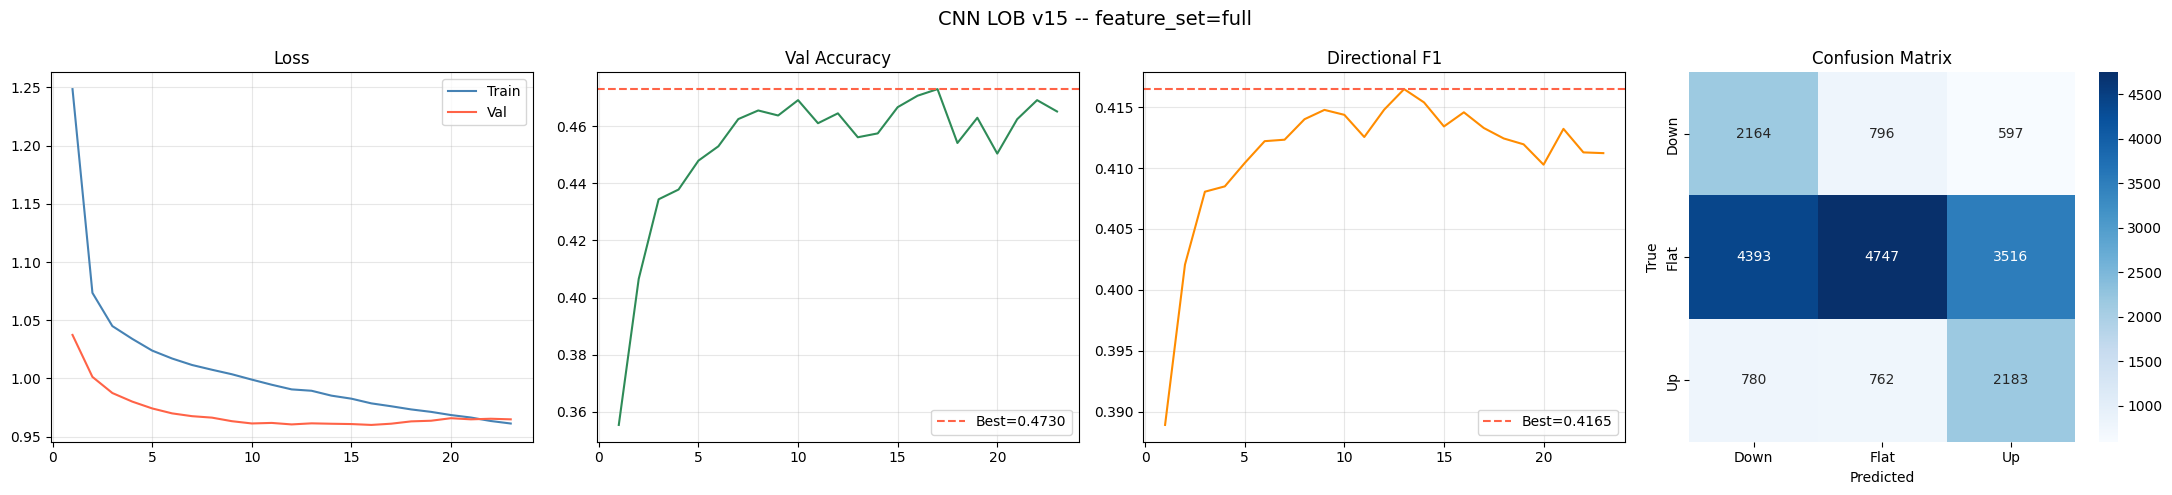


--- Backtest: Argmax (no filter) ---

-------------------------------------------------------
  BACKTEST: Argmax (full)  (Fee: 1.5 bps)
-------------------------------------------------------
  Total Net Return :     37.85%
  Annualized Sharpe:     347.44
  Max Drawdown     :     -3.85%
  Win Rate         :     47.11%
  Active steps     :     13,633 / 19,938  (68.4%)
  Total Turnover   :      6,406  (position changes)

THRESHOLD SWEEP — CNN (full)  (Fee: 1.5 bps)
Best threshold : 0.525
  Sharpe       : 549.87
  Net Return   : 39.53%
  Turnover     : 3,698.0


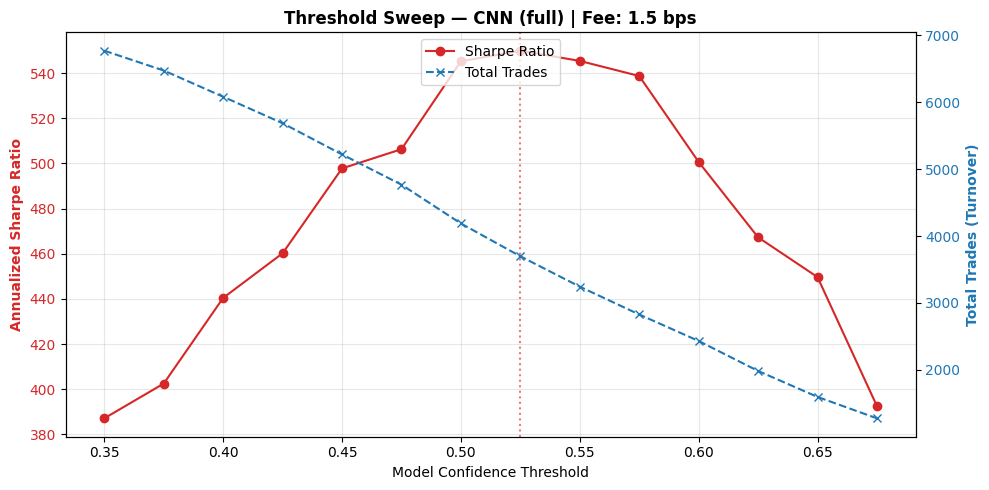


--- Backtest: Optimal threshold = 0.525 ---

-------------------------------------------------------
  BACKTEST: Opt-th=0.525 (full)  (Fee: 1.5 bps)
-------------------------------------------------------
  Total Net Return :     39.53%
  Annualized Sharpe:     549.87
  Max Drawdown     :     -1.46%
  Win Rate         :     54.52%
  Active steps     :      5,712 / 19,938  (28.6%)
  Total Turnover   :      3,698  (position changes)


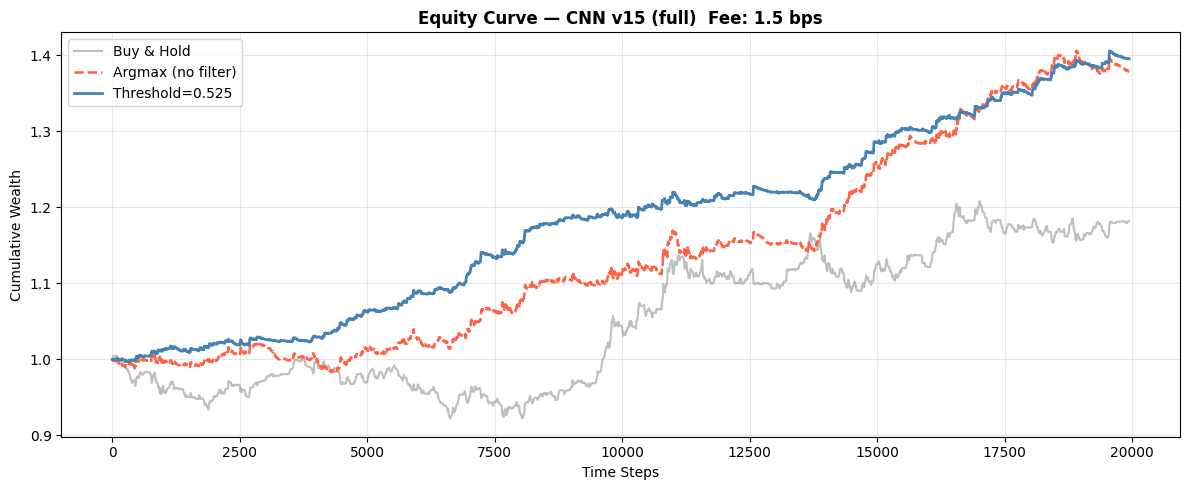

In [7]:
res_full = run_cnn('full')

### Experiment 2: No PCA (Raw LOB + Market)

  CNN LOB v15 -- feature_set = no_pca
Feature set: NO_PCA | features: 88
X shape: (99783, 88) | y shape: (99783,)
Label dist (down/flat/up): [0.216 0.569 0.215]
Train samples: 79817 | Test samples: 19938
Class weights (down/flat/up): [1.481 0.603 1.503]
Model params: 122,051  |  Input features: 88

--- Training ---
Ep   1/50 | Train 1.2529 | Val 1.0184 | Acc 0.4538 | DirF1 0.3947
Ep   2/50 | Train 1.0833 | Val 1.0007 | Acc 0.4460 | DirF1 0.4039
Ep   3/50 | Train 1.0521 | Val 0.9924 | Acc 0.4562 | DirF1 0.4071
Ep   4/50 | Train 1.0374 | Val 0.9861 | Acc 0.4424 | DirF1 0.4077
Ep   5/50 | Train 1.0289 | Val 0.9850 | Acc 0.4382 | DirF1 0.4095
Ep   6/50 | Train 1.0211 | Val 0.9810 | Acc 0.4523 | DirF1 0.4119
Ep   7/50 | Train 1.0169 | Val 0.9768 | Acc 0.4563 | DirF1 0.4130
Ep   8/50 | Train 1.0120 | Val 0.9760 | Acc 0.4420 | DirF1 0.4102
Ep   9/50 | Train 1.0076 | Val 0.9746 | Acc 0.4420 | DirF1 0.4140
Ep  10/50 | Train 1.0039 | Val 0.9717 | Acc 0.4484 | DirF1 0.4141
Ep  11/50 | Train 0.998

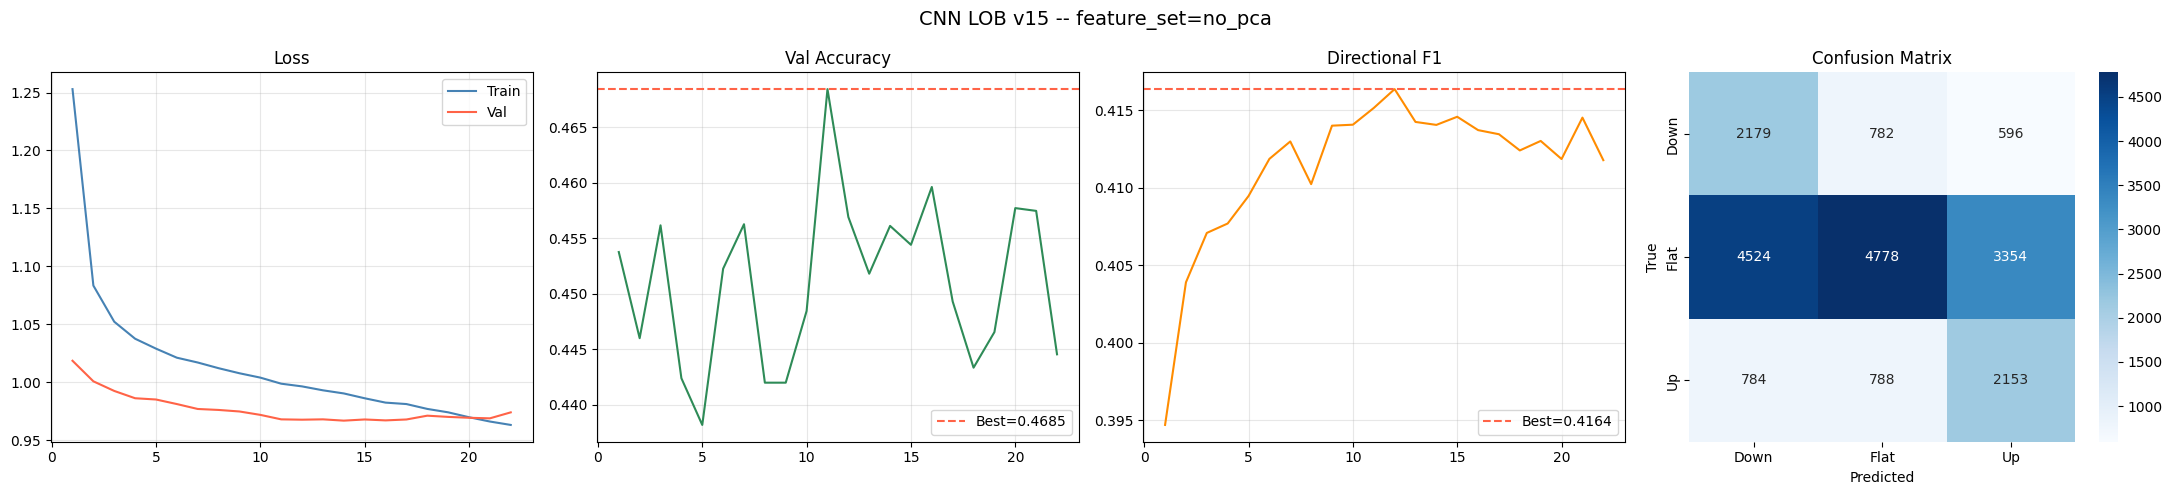


--- Backtest: Argmax (no filter) ---

-------------------------------------------------------
  BACKTEST: Argmax (no_pca)  (Fee: 1.5 bps)
-------------------------------------------------------
  Total Net Return :     40.32%
  Annualized Sharpe:     370.89
  Max Drawdown     :     -3.23%
  Win Rate         :     47.12%
  Active steps     :     13,590 / 19,938  (68.2%)
  Total Turnover   :      6,146  (position changes)

THRESHOLD SWEEP — CNN (no_pca)  (Fee: 1.5 bps)
Best threshold : 0.475
  Sharpe       : 479.26
  Net Return   : 39.00%
  Turnover     : 4,754.0


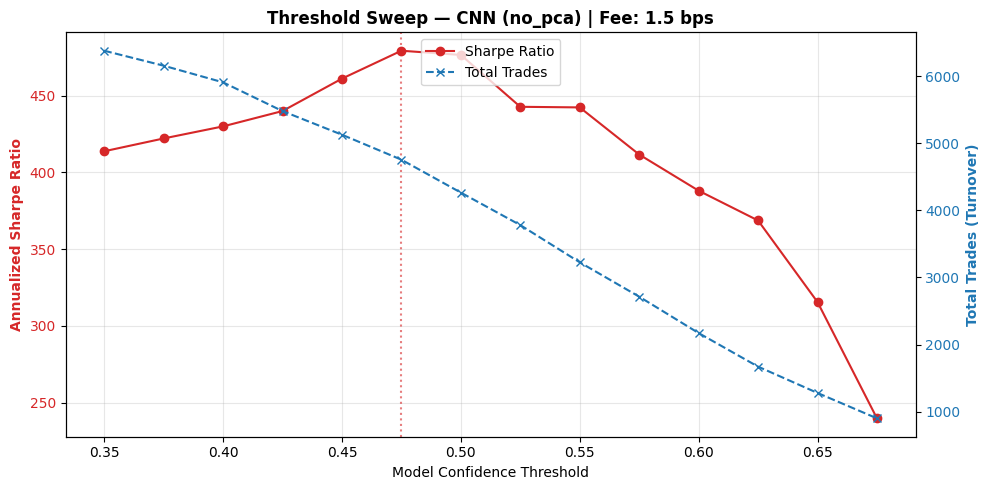


--- Backtest: Optimal threshold = 0.475 ---

-------------------------------------------------------
  BACKTEST: Opt-th=0.475 (no_pca)  (Fee: 1.5 bps)
-------------------------------------------------------
  Total Net Return :     39.00%
  Annualized Sharpe:     479.26
  Max Drawdown     :     -1.56%
  Win Rate         :     51.62%
  Active steps     :      7,822 / 19,938  (39.2%)
  Total Turnover   :      4,754  (position changes)


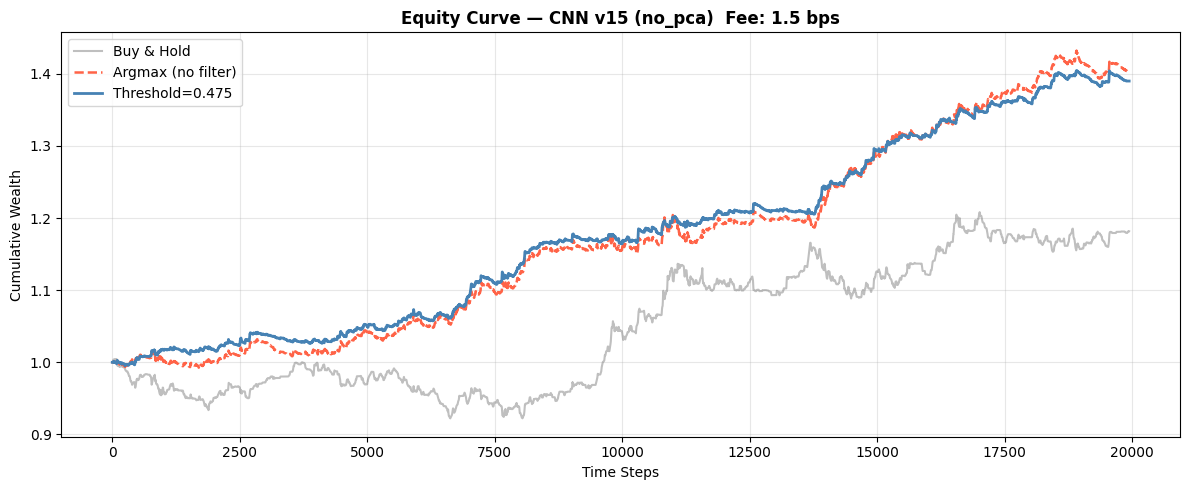

In [8]:
res_nopca = run_cnn('no_pca')

### Experiment 3: No Market (PCA LOB only)

  CNN LOB v15 -- feature_set = no_market
Feature set: NO_MARKET | features: 23
X shape: (99783, 23) | y shape: (99783,)
Label dist (down/flat/up): [0.216 0.569 0.215]
Train samples: 79817 | Test samples: 19938
Class weights (down/flat/up): [1.481 0.603 1.503]
Model params: 117,891  |  Input features: 23

--- Training ---
Ep   1/50 | Train 1.1885 | Val 1.0211 | Acc 0.4019 | DirF1 0.3986
Ep   2/50 | Train 1.0652 | Val 1.0036 | Acc 0.4244 | DirF1 0.4061
Ep   3/50 | Train 1.0486 | Val 0.9949 | Acc 0.4255 | DirF1 0.4093
Ep   4/50 | Train 1.0354 | Val 0.9886 | Acc 0.4408 | DirF1 0.4114
Ep   5/50 | Train 1.0304 | Val 0.9866 | Acc 0.4344 | DirF1 0.4125
Ep   6/50 | Train 1.0259 | Val 0.9833 | Acc 0.4487 | DirF1 0.4162
Ep   7/50 | Train 1.0208 | Val 0.9824 | Acc 0.4377 | DirF1 0.4148
Ep   8/50 | Train 1.0151 | Val 0.9780 | Acc 0.4527 | DirF1 0.4165
Ep   9/50 | Train 1.0135 | Val 0.9760 | Acc 0.4514 | DirF1 0.4186
Ep  10/50 | Train 1.0113 | Val 0.9779 | Acc 0.4421 | DirF1 0.4184
Ep  11/50 | Train

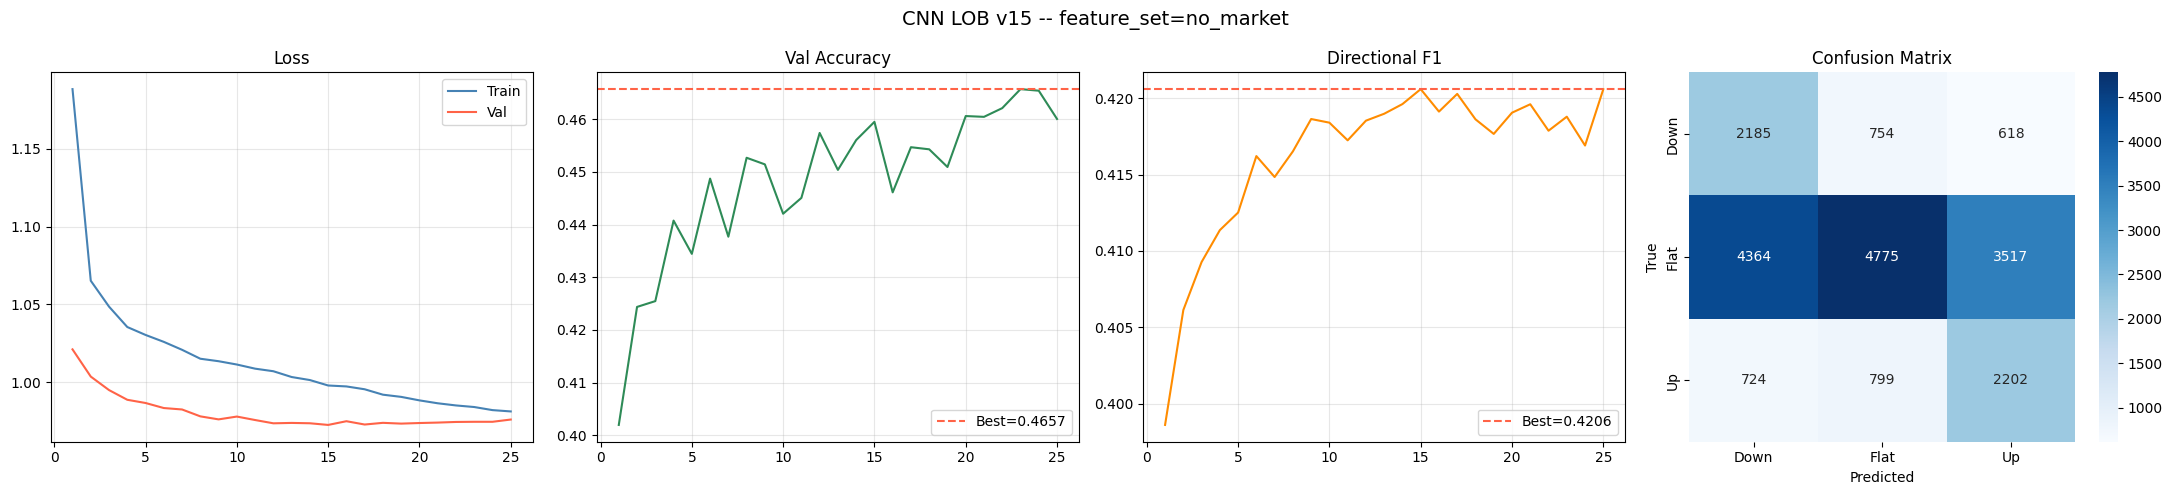


--- Backtest: Argmax (no filter) ---

-------------------------------------------------------
  BACKTEST: Argmax (no_market)  (Fee: 1.5 bps)
-------------------------------------------------------
  Total Net Return :     41.80%
  Annualized Sharpe:     378.11
  Max Drawdown     :     -3.58%
  Win Rate         :     47.45%
  Active steps     :     13,610 / 19,938  (68.3%)
  Total Turnover   :      6,162  (position changes)

THRESHOLD SWEEP — CNN (no_market)  (Fee: 1.5 bps)
Best threshold : 0.525
  Sharpe       : 546.71
  Net Return   : 38.84%
  Turnover     : 3,560.0


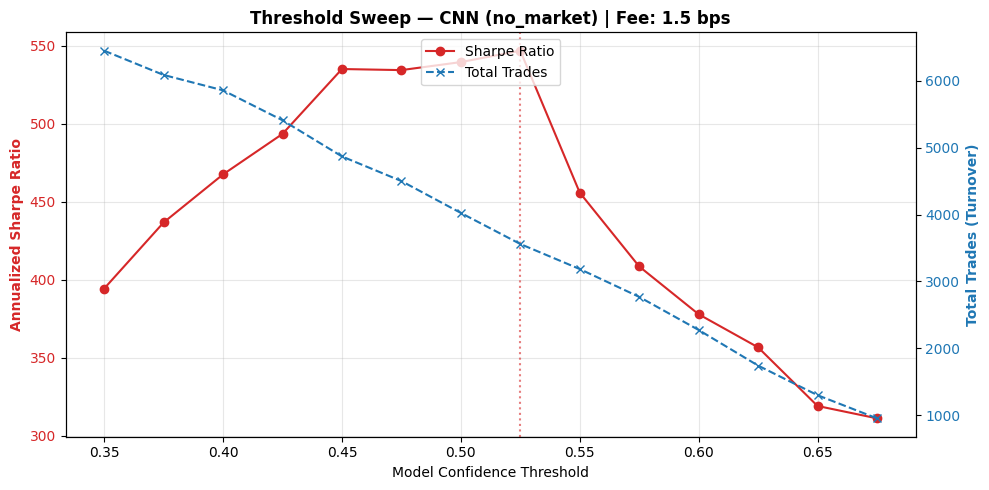


--- Backtest: Optimal threshold = 0.525 ---

-------------------------------------------------------
  BACKTEST: Opt-th=0.525 (no_market)  (Fee: 1.5 bps)
-------------------------------------------------------
  Total Net Return :     38.84%
  Annualized Sharpe:     546.71
  Max Drawdown     :     -1.22%
  Win Rate         :     55.00%
  Active steps     :      5,658 / 19,938  (28.4%)
  Total Turnover   :      3,560  (position changes)


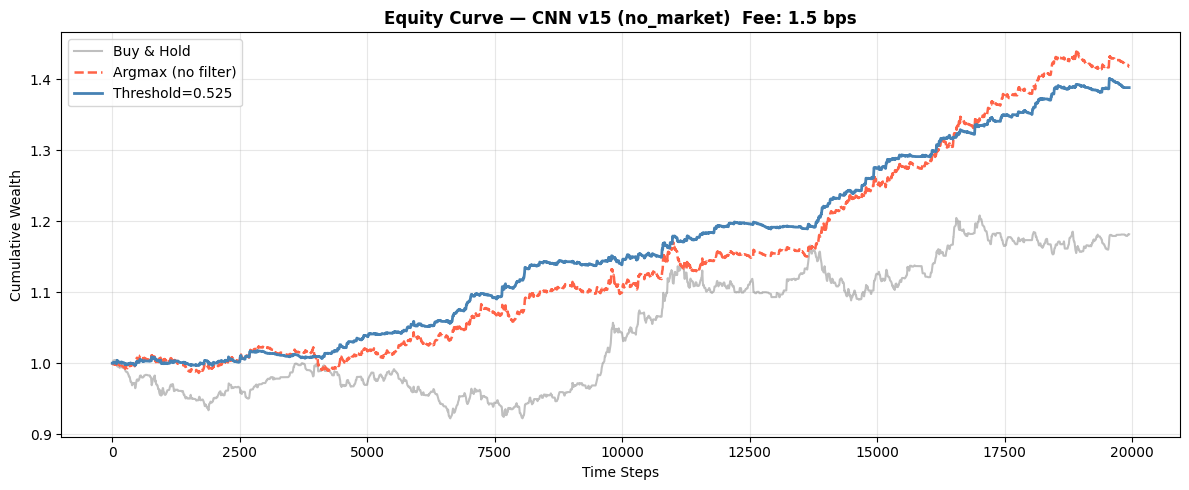

In [9]:
res_nomarket = run_cnn('no_market')

## Ablation Summary

In [10]:
print('=' * 75)
print(f'ABLATION SUMMARY  —  CNN v15  |  Fee: {FEE*10000:.1f} bps')
print(f'Architecture: N_FILTERS={N_FILTERS} | DROPOUT={DROPOUT} | WD={WD} | CosineAnnealingLR')
print('=' * 75)
print(f'{"Feature Set":<12} | {"Acc":>6} | {"DirF1":>7} | '
      f'{"Argmax Ret":>11} | {"Argmax Sh":>10} | '
      f'{"Opt-Th":>7} | {"Opt Ret":>9} | {"Opt Sh":>8} | {"Opt DD":>8}')
print('-' * 95)
for res in [res_full, res_nopca, res_nomarket]:
    print(f'{res["feature_set"]:<12} | '
          f'{res["acc"]:>6.4f} | '
          f'{res["best_dir_f1"]:>7.4f} | '
          f'{res["argmax_ret"]:>11.2%} | '
          f'{res["argmax_sh"]:>10.2f} | '
          f'{res["opt_th"]:>7.3f} | '
          f'{res["opt_ret"]:>9.2%} | '
          f'{res["opt_sh"]:>8.2f} | '
          f'{res["opt_dd"]:>8.2%}')

ABLATION SUMMARY  —  CNN v15  |  Fee: 1.5 bps
Architecture: N_FILTERS=64 | DROPOUT=0.3 | WD=0.01 | CosineAnnealingLR
Feature Set  |    Acc |   DirF1 |  Argmax Ret |  Argmax Sh |  Opt-Th |   Opt Ret |   Opt Sh |   Opt DD
-----------------------------------------------------------------------------------------------
full         | 0.4561 |  0.4165 |      37.85% |     347.44 |   0.525 |    39.53% |   549.87 |   -1.46%
no_pca       | 0.4569 |  0.4164 |      40.32% |     370.89 |   0.475 |    39.00% |   479.26 |   -1.56%
no_market    | 0.4595 |  0.4206 |      41.80% |     378.11 |   0.525 |    38.84% |   546.71 |   -1.22%
